In [2]:
# Run this in your first cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For pretty plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv("../data/netflix_titles.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (8807, 12)

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


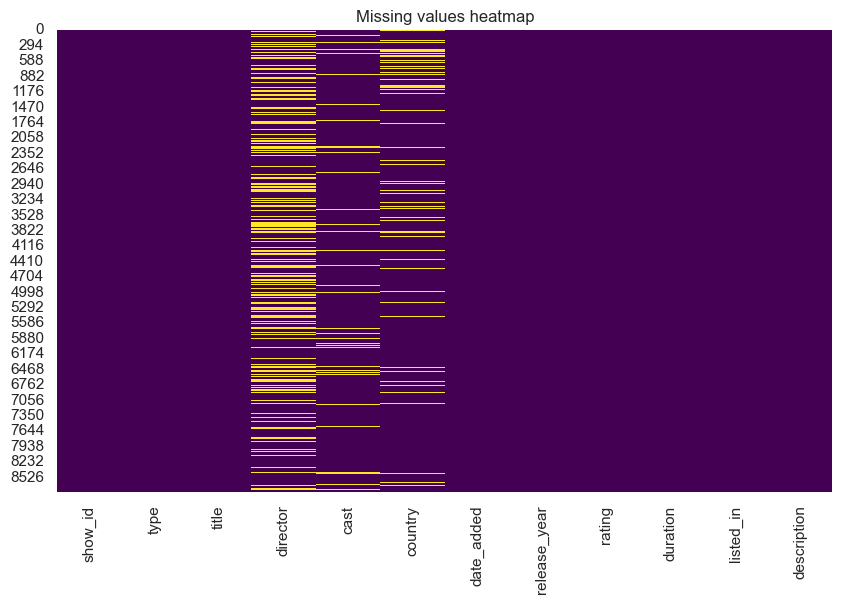

In [4]:
print("Missing values:")
print(df.isnull().sum())

# Optional: visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing values heatmap")
plt.show()

In [5]:
# Replace missing director/cast with "Unknown"
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")

# Replace missing country with the most common country
most_common_country = df["country"].mode()[0]
df["country"] = df["country"].fillna(most_common_country)

# Drop rows where date_added is missing (only a few rows)
df = df.dropna(subset=["date_added"])

print("Data cleaned. Shape:", df.shape)

Data cleaned. Shape: (8797, 12)


In [6]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

# Save cleaned data
df.to_csv("../data/netflix_titles_cleaned.csv", index=False)
print("Cleaned data saved to'../data/netflix_titles_cleaned.csv'")

Duplicates before: 0
Duplicates after: 0
Cleaned data saved to'../data/netflix_titles_cleaned.csv'
